## The full journey: From a corpus to its graph
![](img/processing_chain.jpg)

### Get prepared

#### Install moduls for lemmatization and vectorization

`python -m pip install -U pip setuptools wheel`   
`python -m pip install -U spacy`   
`python -m spacy download en_core_web_sm`

#### Imports for text cleaning, lemmatization, and vectorization

In [1]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter 
import pandas as pd
pd.options.display.max_rows = 600
import spacy
from bs4 import BeautifulSoup 
import glob
from pathlib import Path
import re
import networkx as nx
from networkx.algorithms import bipartite
import matplotlib.pyplot as plt
import json

#### Read stopwords into `stopw` variable

In [2]:
file = 'stopwords/stopwords_en_nl'
with open(file, 'r', encoding='utf-8') as stop:
    stopw = stop.read()
stopw = stopw.split('\n')
#stopw

#### Load Spacy language model for english for lemmatization

In [3]:
nlp = spacy.load("en_core_web_sm")

---

### US Presidential Inaugural Addresses

During Barack Obama’s Inaugural Address in January 2009, he mentioned “women” four different times. We may ask: How distinctive is Obama’s inclusion of women in this address compared to all other U.S. 
Presidents? 

We proceed in four steps:

1. Clean and lemmatize texts in corpus
2. Vectorize the corpus yielding dfidf scores for terms in the graph
3. Construct graph from terms having dfidf scores above given threshold
4. Make SVG file for the graph 

#### Clean and lemmatize

![](img/Lemmatization.jpg)

In [4]:
directory_path = "./datasets/US_Pres_Inaug_Addr/"
text_files = glob.glob(f"{directory_path}/*.txt")
text_titles = [Path(text).stem for text in text_files]
addresses = []
add_concat = []
xx = []
yy = []
for text_file in text_files:
    with open(text_file, 'r', encoding='utf-8') as file:
        content = file.read()
        content = content.lower()
        content = content.split('\t')[2].replace('\n',' ')
        soup = BeautifulSoup(content, 'html.parser')
        text_no_tags = soup.get_text()
        #print(f"\nLength before stopword removal and lemmatization: {len(text_no_tags)} for {Path(text_file).stem}")
        xx.append(len(text_no_tags))
        doc = nlp(text_no_tags)
        text_lemmatized_list = [token.lemma_ for token in doc if token.text not in stopw and not token.is_punct and not token.lemma_ in stopw]
        text_lemmatized = ' '.join(text_lemmatized_list)
        text = re.sub(r'\$?\s*\d+[,\d+]+', '', text_lemmatized)
        #print (text)
        #print(f"Length after stopw removal and lemmatization:  {len(text)}")
        yy.append(len(text))
        addresses.append(text)
        file.close()
txt_reduct_df = pd.DataFrame({'address' : text_titles, 'before': xx, 'after': yy})
num_nodes_to_inspect = 40


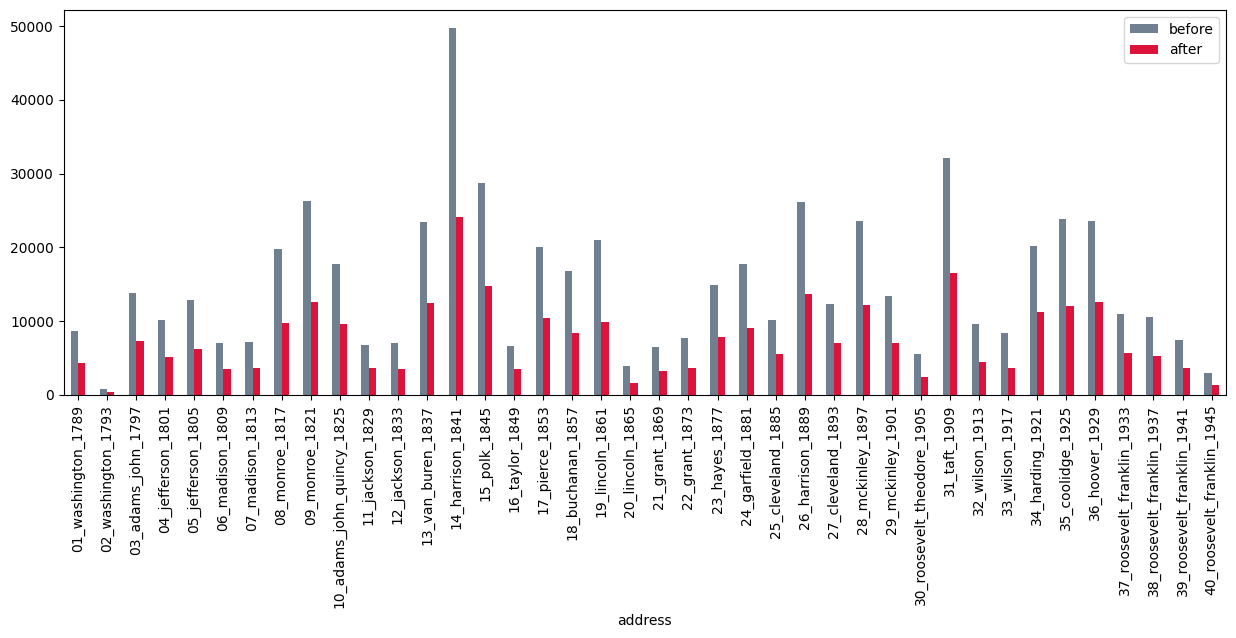

In [5]:
txt_reduct_df[:num_nodes_to_inspect].plot(x='address', y=['before', 'after'], color=['SlateGray', 'Crimson'], figsize=(15,5), kind='bar')
# compute term frequency dict
addr_concat = ' '.join(addresses)
zz = dict(Counter(addr_concat.split()))
zz = dict(sorted(zz.items()))
term_frq = {k:v for k,v in zz.items()}
#list(term_frq.items())[:15] 

---

### Vectorize

![](img/bag-of-words-vector.webp)

#### Apply tf-idf

In [6]:
# Fit and transform the presidential addresses using TF-IDF
tfidf_vectorizer = TfidfVectorizer(input='content')
tfidf_vector = tfidf_vectorizer.fit_transform(addresses)
# Make a DataFrame out of the resulting tf–idf vector, setting the "feature names" (terms) as columns and the address titles (i.e. file names) as rows
tfidf_df = pd.DataFrame(tfidf_vector.toarray(), index=text_titles, columns=tfidf_vectorizer.get_feature_names_out())
print ('Terms in dataframe: ',len(tfidf_df.columns))
# Display the DataFrame
tfidf_slice = tfidf_df[['government', 'border', 'people', 'obama', 'war', 'honor','foreign', 'man', 'woman', 'child']]
tfidf_slice.sort_index().round(decimals=2).tail(15)

Terms in dataframe:  6212


,government,border,people,obama,war,honor,foreign,man,woman,child
44_kennedy_1961,0.02,0.04,0.03,0.00,0.07,0.00,0.00,0.08,0.00,0.00
45_johnson_1965,0.01,0.00,0.12,0.00,0.02,0.00,0.02,0.18,0.00,0.10
46_nixon_1969,0.06,0.00,0.16,0.00,0.04,0.03,0.00,0.13,0.00,0.02
47_nixon_1973,0.12,0.00,0.07,0.00,0.07,0.02,0.00,0.00,0.00,0.02
48_carter_1977,0.07,0.00,0.11,0.00,0.04,0.00,0.02,0.02,0.00,0.00
49_reagan_1981,0.17,0.00,0.09,0.00,0.01,0.00,0.00,0.09,0.04,0.09
50_reagan_1985,0.18,0.00,0.15,0.00,0.01,0.01,0.00,0.07,0.04,0.00
51_bush_george_h_w_1989,0.05,0.00,0.07,0.00,0.04,0.00,0.02,0.10,0.09,0.09
52_clinton_1993,0.05,0.00,0.14,0.00,0.03,0.00,0.02,0.01,0.03,0.09
53_clinton_1997,0.10,0.00,0.11,0.00,0.02,0.00,0.00,0.01,0.02,0.12


#### Get document frequency for terms

In [7]:
doc_frq = (tfidf_df > 0).sum().to_dict()
doc_frq = {k: v for k, v in doc_frq.items() if v > 0}
list(doc_frq.items())[:15]

[('1st', 1),
 ('3d', 1),
 ('4th', 1),
 ('6th', 1),
 ('abandon', 12),
 ('abandonment', 4),
 ('abate', 1),
 ('abdicate', 1),
 ('abeyance', 1),
 ('abhor', 1),
 ('abide', 12),
 ('abiding', 1),
 ('ability', 21),
 ('abject', 1),
 ('ably', 1)]

---

### Create graph

#### Reframe tfidf dataframe

In [8]:
# Let's reframe the tfidf dataFrame so that the terms are in rows rather than columns.
df_stacked = tfidf_df.stack().reset_index().rename(columns={0:'tfidf', 'level_0': 'address','level_1': 'term'})
print (df_stacked.tail(50))

              address            term     tfidf
360246  58_trump_2017        woodsman  0.000000
360247  58_trump_2017            word  0.000000
360248  58_trump_2017            work  0.015160
360249  58_trump_2017          worker  0.078392
360250  58_trump_2017       workforce  0.000000
360251  58_trump_2017         working  0.000000
360252  58_trump_2017      workingman  0.000000
360253  58_trump_2017      workingmen  0.000000
360254  58_trump_2017     workmanship  0.000000
360255  58_trump_2017        workshop  0.000000
360256  58_trump_2017           world  0.000000
360257  58_trump_2017         worldly  0.000000
360258  58_trump_2017       worldwide  0.000000
360259  58_trump_2017            worm  0.000000
360260  58_trump_2017           worry  0.000000
360261  58_trump_2017         worship  0.000000
360262  58_trump_2017           worth  0.000000
360263  58_trump_2017        worthily  0.000000
360264  58_trump_2017       worthless  0.000000
360265  58_trump_2017          worthy  0

<Axes: xlabel='tf-idf values', ylabel='Frequency'>

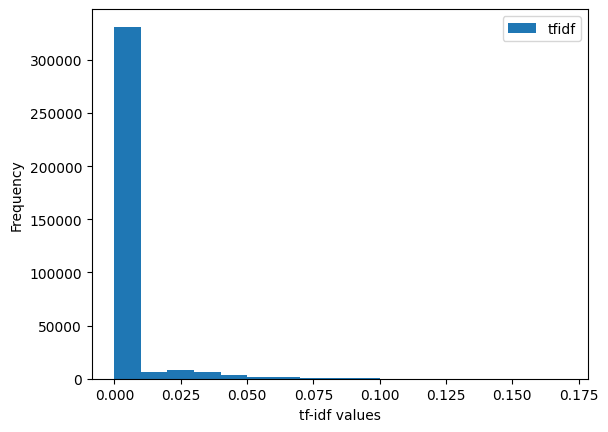

In [9]:
seq = [0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17]
df_stacked.plot(kind='hist', column = 'tfidf', bins=seq, xlabel='tf-idf values')

<Axes: xlabel='tf-idf values', ylabel='Frequency'>

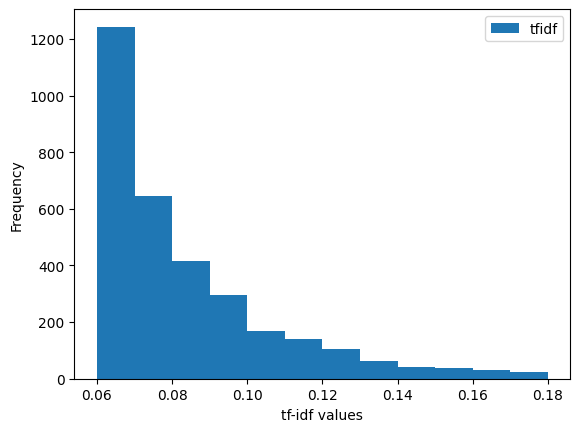

In [10]:
seq = [0.06, 0.07, 0.08, 0.09, 0.1, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18]
df_stacked.plot(kind='hist', column='tfidf', bins=seq,  xlabel='tf-idf values')

#### Set threshold for tf-idf score

In [11]:
threshold = float(input('Set threshold for tf-idf score: '))

#### Accept terms only, if their tfidf value is greater than chosen threshold

In [12]:
print ('count rows in full dataframe: ', len(df_stacked.index))
# Set threshold for TF-IDF values and determine remaining terms
thres_tfidf = df_stacked[df_stacked['tfidf'] >= threshold]
print ('count rows in reduced dataframe: ', len(thres_tfidf.index))
thres_tfidf

count rows in full dataframe:  360296
count rows in reduced dataframe:  250


,address,term,tfidf
6563,02_washington_1793,arrive,0.207717
6992,02_washington_1793,ceremony,0.182085
7869,02_washington_1793,distinguished,0.149792
8131,02_washington_1793,entertain,0.145712
8246,02_washington_1793,execution,0.169399
9096,02_washington_1793,incur,0.219243
9188,02_washington_1793,injunction,0.219243
9225,02_washington_1793,instance,0.163898
9437,02_washington_1793,knowingly,0.233349
9612,02_washington_1793,magistrate,0.182085


In [13]:
print(thres_tfidf[thres_tfidf['term'] == 'government'].value_counts().sum())

19


#### Assign presidential address ID (aka file name) to terms
needed for viz

In [14]:
used_in = {}
for term in thres_tfidf['term']:
    ad = list(thres_tfidf[thres_tfidf['term'] == term]['address'])
    d = {term: ad}
    used_in.update(d)

#### Create dict for setting node 'id' attribute
needed for viz

In [15]:
ids = thres_tfidf['term'].unique().tolist()
ids_dict = {k:v for k, v in zip(ids, ids)}
#print (ids_dict)

#### Create graph by projection

In [16]:
# Now, convert the data frame to a graph by projecting the bipartite graph
B = nx.Graph(created_by='fruschtique')
X = nx.Graph(created_by='fruschtique')
top    = thres_tfidf['address'].unique()
#print (top)
bottom = thres_tfidf['term'].unique()
#print (bottom)
e_list = []
for index, row in thres_tfidf.iterrows():
    e_list.append((row['address'], row['term']))
B.add_nodes_from(top, bipartite=0)
B.add_nodes_from(bottom, bipartite=1)
B.add_edges_from(e_list)
X = bipartite.weighted_projected_graph(B, bottom)
print ('Node count:    ', len(X.nodes()))
print ('Edge count:    ', len(X.edges()))
print ('Graph density: ', nx.density(X))

Node count:     153
Edge count:     604
Graph density:  0.05194358445132439


#### Set node attributes

In [17]:
nx.set_node_attributes(X, ids_dict, 'id')
nx.set_node_attributes(X, term_frq, 'term_frq')
nx.set_node_attributes(X, doc_frq, 'doc_frq') 
nx.set_node_attributes(X, dict(X.degree()), 'degree')
nx.set_node_attributes(X, dict(nx.betweenness_centrality(X)), 'betweenness')
nx.set_node_attributes(X, dict(nx.closeness_centrality(X)), 'closeness')
nx.set_node_attributes(X, used_in, 'used_in')
#for node, data in X.nodes(data=True):
#    print(f"Node: {node}, Attributes: {data}") 

As for edge attributes: 
Edge attribute 'weight' is set when projecting the bipartite graph. We don't need any further edge attributes at the moment.

#### Inspect graph attributes

document frequency

            node  doc_frq
3671      nation       57
4007      people       56
2505       great       56
1229     country       55
2477  government       55
...          ...      ...
6192     writing        1
0            1st        1
15      abnormal        1
14          ably        1
13        abject        1

[6212 rows x 2 columns]


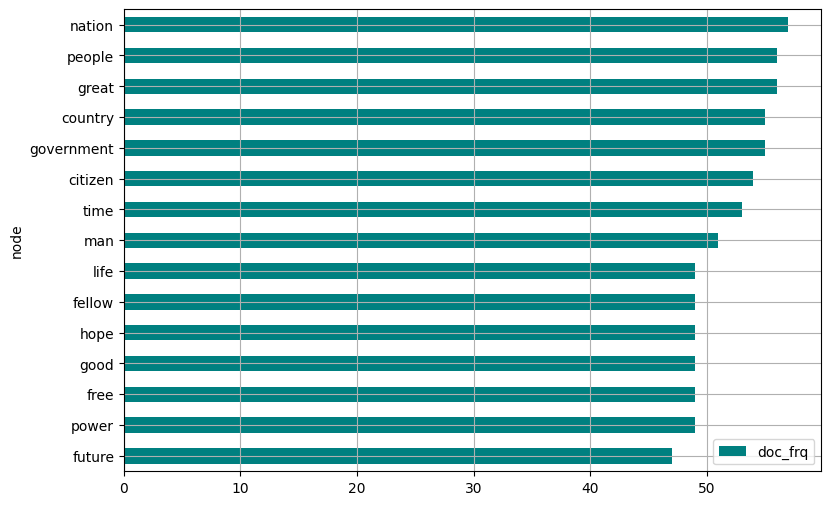

In [17]:
x = {'node': list(doc_frq.keys()), 'doc_frq':list(doc_frq.values())}
doc_frq_df = pd.DataFrame(data=x)
doc_frq_df = doc_frq_df.sort_values(by='doc_frq', ascending=False)
print (doc_frq_df)
num_nodes_to_inspect = 15
doc_frq_df[:num_nodes_to_inspect].plot(x='node', y='doc_frq', color='teal', kind='barh', figsize=[9,6], grid=True).invert_yaxis()

term frequency

 Min term_frq:  1 
 Max term_frq:  654


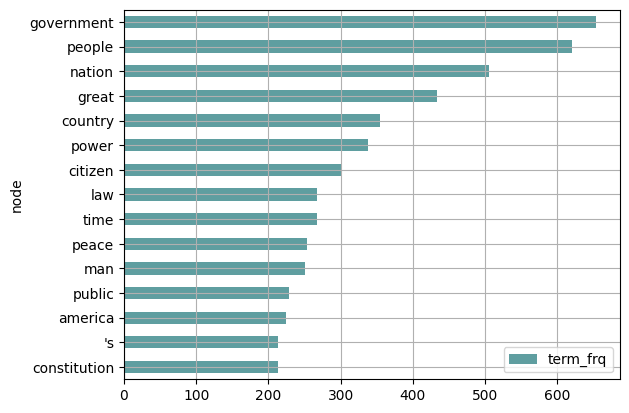

In [18]:
x = {'node': list(term_frq.keys()), 'term_frq':list(term_frq.values())}
term_frq_df = pd.DataFrame(data=x)
term_frq_df = term_frq_df.sort_values(by='term_frq', ascending=False)
print (" Min term_frq: ", term_frq_df["term_frq"].min(), '\n', "Max term_frq: ", term_frq_df["term_frq"].max())
num_nodes_to_inspect = 15
term_frq_df[:num_nodes_to_inspect].plot(x='node', y='term_frq', color='cadetblue', kind='barh', grid=True).invert_yaxis()

degree

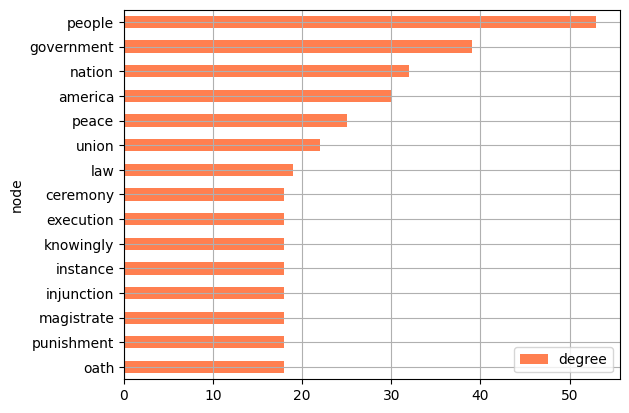

In [19]:
#print (list(X.degree()))
x = {'node': list(nx.get_node_attributes(X, "degree").keys()), 'degree':list(nx.get_node_attributes(X, "degree").values())}
degree_df = pd.DataFrame(data=x)
#print (degree_df)
degree_df = degree_df.sort_values(by='degree', ascending=False)
num_nodes_to_inspect = 15
degree_df[:num_nodes_to_inspect].plot(x='node', y='degree', color='coral', kind='barh', grid=True).invert_yaxis()

betweenness

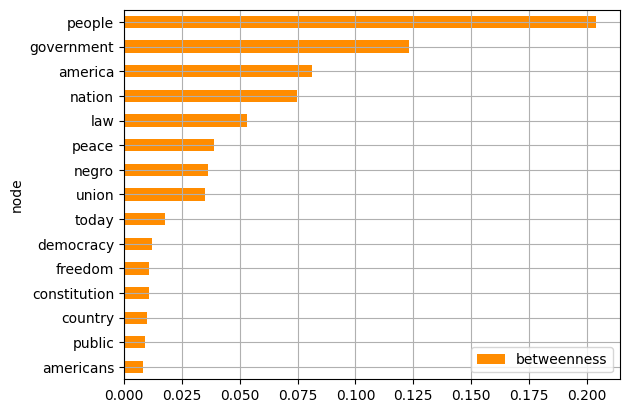

In [20]:
x = {'node': list(nx.get_node_attributes(X, "betweenness").keys()), 'betweenness':list(nx.get_node_attributes(X, "betweenness").values())}
betweenness_df = pd.DataFrame(data=x)
betweenness_df = betweenness_df.sort_values(by='betweenness', ascending=False)
num_nodes_to_inspect = 15
betweenness_df[:num_nodes_to_inspect].plot(x='node', y='betweenness', color='darkorange', kind='barh', grid=True).invert_yaxis()

#### Serialize to node-link format

In [33]:
fn = f'graphs/USPresInaugAddr_{threshold}.json'
with open(fn, 'w', encoding='utf-8') as f:
    json.dump(nx.node_link_data(X), f, indent=2, ensure_ascii=False)

---

### Initial visualization (nx.draw)

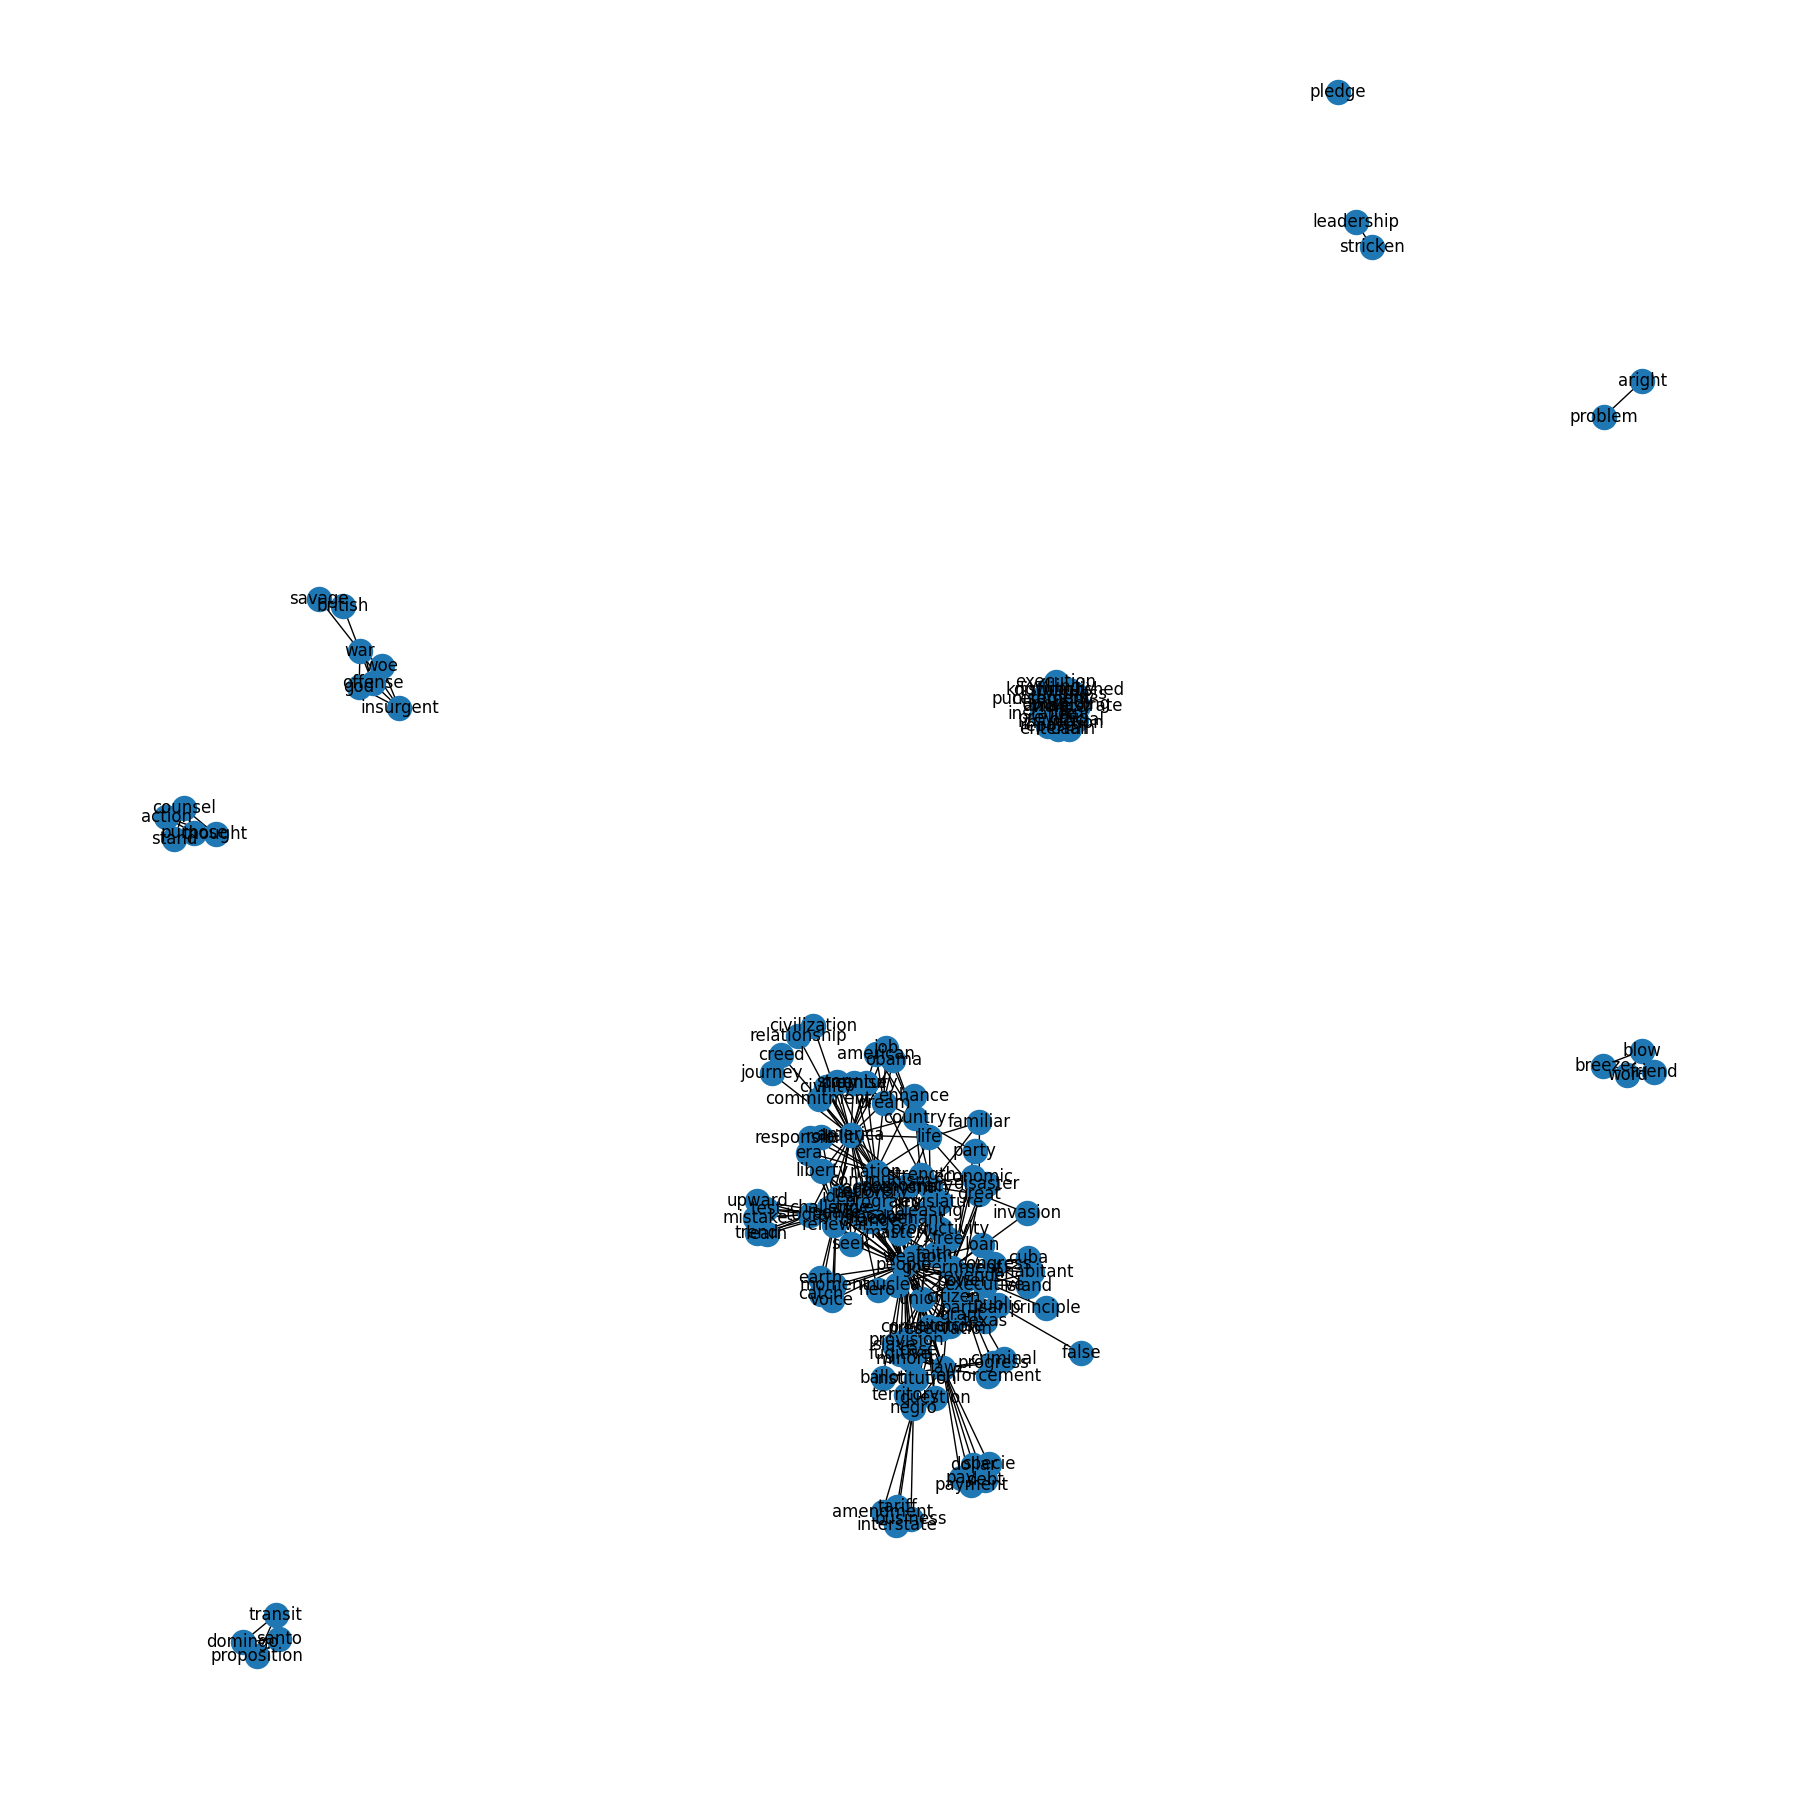

In [18]:
pos = nx.spring_layout(X)
plt.figure(figsize=(18, 18))
nx.draw(X, pos, with_labels=True)   
plt.show()